## 📋 Function minimization

This week's lecture explored how training a model involves finding an optimal set of weights (parameters) by minimizing an error function.

Scipy offers several methods, like <b> `fmin_bfgs` </b>, for identifying the minima of complex functions. This method uses the [BFGS optimization algorithm](https://en.wikipedia.org/wiki/Broyden%E2%80%93Fletcher%E2%80%93Goldfarb%E2%80%93Shanno_algorithm) to identify the minimum of a function.

To use it, we need to provide the following arguments:

- **`f`**: The target function we want to minimize.
- **`x0`**: An initial guess for the value at which the function achieves its minimum.
- **`fprime`** (optional): The first derivative of the target function. If omitted, `fmin_bfgs` will approximate it numerically.
---



In [2]:
import numpy

from scipy.optimize import fmin_bfgs, fmin


### 🔍 Let's minimize the polynomial function:

$$
f(x) = x^4 - 10x^3 + x^2 + x - 4
$$


In [3]:
def f(x):
    """Polynomial objective used to illustrate local and global minima."""
    return x**4 - 10*x**3 + x**2 + x - 4


def fprime(x):
    """First derivative of f(x), used by BFGS to follow the local slope."""
    return 4*x**3 - 30*x**2 + 2*x + 1

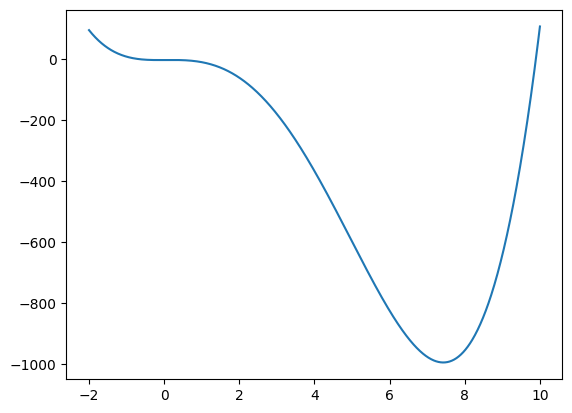

In [4]:
# The following lines will import the matplotlib library and enable plots to appear in the body of the notebook.
%matplotlib inline
from matplotlib import pyplot

x = numpy.linspace(-2,10,1000)
pyplot.plot(x,f(x))

### 🔍 Let's find the minimum, using 0 as a starting point:

In [5]:
# x0 = initial guess for where the optimizer starts searching.
# fprime = exact derivative, so BFGS can follow the slope directly.
print(fmin_bfgs(f, x0=0, fprime=fprime))

Optimization terminated successfully.
         Current function value: -4.093250
         Iterations: 5
         Function evaluations: 8
         Gradient evaluations: 8
[-0.15101745]


### 🔍 Estimating derivative of $𝑓$

- Next, let's omit the explicit derivative of $𝑓$ and allow fmin_bfgs to estimate the derivative numerically. We expect the results to be quite similar


In [6]:
# x0 = initial guess for the minimum.
# Without fprime, BFGS estimates the derivative numerically from nearby function values.
print(fmin_bfgs(f, x0=0))

Optimization terminated successfully.
         Current function value: -4.093250
         Iterations: 5
         Function evaluations: 16
         Gradient evaluations: 8
[-0.15101746]


We can suppress the messages using disp=False:

In [7]:
# x0 = initial guess for the minimum.
# disp=False hides the optimizer's progress messages so only the solution is printed.
print(fmin_bfgs(f, x0=0, disp=False))

[-0.15101746]


### 📝 Exercise 1 Local minimum
Looks like we got stuck in a local miniumum. Print the values of `x` where `f(x)` has a minimum findable from the following starting points: -2, 0, 2, 6, 10

In [8]:
# x0 = starting point given to the optimizer.
# Different starting points can fall into different valleys when the function has local minima.
for x0 in [-2, 0, 2, 6, 10]:
    x_min = float(fmin_bfgs(f, x0=x0, fprime=fprime, disp=False)[0])
    print("Starting at {} found minimum at {}".format(x0, x_min))

Starting at -2 found minimum at -0.15101773937335594
Starting at 0 found minimum at -0.1510174530294978
Starting at 2 found minimum at 7.428157729022677
Starting at 6 found minimum at 7.428157720283418
Starting at 10 found minimum at 7.428157731049425



- We can also use `fmin_bfgs` to minimize functions which take vectors rather than single numbers. For example, let's find the $x_1$ and $x_2$ which minimize the function $g(\mathbf{x}) = x_1^2 + x_2^2$ .

In [9]:
def g(x):
    """Return the squared distance from the origin for a vector x."""
    return (x**2).sum()

# x0 and x1 are two different initial guesses for the vector-valued optimizer.
# each will converge to a different mi
x0 = numpy.array([-1, -1])
x1 = numpy.array([1, 1])

print("Starting at {} found minimum at {}".format(x0, fmin_bfgs(g, x0=x0, disp=False)))
print("Starting at {} found minimum at {}".format(x1, fmin_bfgs(g, x0=x1, disp=False)))

Starting at [-1 -1] found minimum at [-7.13245457e-09 -7.13245452e-09]
Starting at [1 1] found minimum at [-1.07505143e-08 -1.07505143e-08]


### 📝 Exercise 2 Error function

In this exercise we will regress the fourth feature of the iris dataset agains the first three, using error function minimization:

- First prepare the data. We will use the function `train_test_split` from [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) to split the data into training and validation portions.
- The named argument `random_state=` sets the random seed and makes sure we will get the same split every time.

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()

X_train, X_val, y_train, y_val = train_test_split(iris.data[:,:3], 
                                                  iris.data[:,3], 
                                                  test_size=1/3, 
                                                  random_state=666)

Now define the error function on training data:

In [11]:
# wb is a list, where the first element is the bias term, and the rest are weights

def error(wb):
    """Return the training sum of squared errors for one intercept/weight vector."""

    # We'll get the intercept as the first element of wb, and the coefficients as the rest.
    b = wb[0]
    w = wb[1:]

    # Predict with y = Xw + b, then sum the squared residuals.
    y_pred = X_train.dot(w) + b
    return ((y_train - y_pred) ** 2).sum()

Let's define a starting point for the intercept and coefficients

In [12]:
# First item is the intercept b, the rest the coefficients w
wb0 = numpy.array([0.0, 0.0, 0.0, 0.0])

Now we are ready to find the values which minimize the error.

In [13]:
# x0 = initial intercept-and-weight guess.
# BFGS starts from wb0 and iteratively updates it toward lower training error.
wb_min = fmin_bfgs(error, x0=wb0)
print(wb_min)

Optimization terminated successfully.
         Current function value: 2.869665
         Iterations: 5
         Function evaluations: 45
         Gradient evaluations: 9
[-0.26721216 -0.22346359  0.24483245  0.53565652]


The model that we have calculated above cannot be visualised as it contains >3 dimensions. 

### 📝 Exercise 3 MAE and r-squared

Let's check how well these parameters do on validation data, in terms of mean absolute error and r-squared. 

In [14]:
from sklearn.metrics import r2_score, mean_absolute_error

b = wb_min[0]
w = wb_min[1:]

# Use the optimized intercept and weights to predict the validation targets.
y_pred_val = X_val.dot(w) + b

# Higher r2 is better; lower MAE is better.
r2 = r2_score(y_val, y_pred_val)
MAE = mean_absolute_error(y_val, y_pred_val)

print('r2 = {}'.format(r2))
print('MAE = {}'.format(MAE))

r2 = 0.9151577701287624
MAE = 0.16703525162846006


### 📝 Exercise 4 Linear regression
Train a [linear regression]( https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html) model using training data we created earlier. 

And, compare the results with the classic implementation of linear regression (Exercise 3).

In [15]:
from sklearn.linear_model import LinearRegression

# Fit the closed-form linear regression model on the training split.
model = LinearRegression()
model.fit(X_train, y_train)

# Inspect the learned parameters.
print('weights: {}'.format(model.coef_))
print('bias: {}'.format(model.intercept_))

# Predict the validation targets and score the model.
y_pred_val = model.predict(X_val)
r2 = r2_score(y_val, y_pred_val)
MAE = mean_absolute_error(y_val, y_pred_val)

print('r2 = {}'.format(r2))
print('MAE = {}'.format(MAE))

print('Difference in intercept vs. BFGS solution: {}'.format(abs(model.intercept_ - wb_min[0])))
print('Difference in weights vs. BFGS solution: {}'.format(numpy.abs(model.coef_ - wb_min[1:])) )

weights: [-0.22346222  0.24483198  0.53565595]
bias: -0.2672166046038511
r2 = 0.915157785470172
MAE = 0.1670352652483977
Difference in intercept vs. BFGS solution: 4.44781711772535e-06
Difference in weights vs. BFGS solution: [1.37752609e-06 4.68630741e-07 5.75202843e-07]


---

## ℹ️ Stochastic Gradient Descent



SGD methods are particularly valuable in the following scenarios:

- **Very large datasets**, as they scale efficiently.
- **Streaming data**, due to their capability for online (incremental) learning.
- **Datasets with sparse features**, as they handle sparsity efficiently.

<details>

<summary> Scaling features for SGD </summary>

SGD algorithms are sensitive to the **learning rate** and the **scale of input features**. To achieve optimal performance, it's recommended to standardize your features using **z-scoring**, i.e. subtracting the mean and dividing by the standard deviation. 

> Scikit-learn simplifies this process through its built-in [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) class.


</details>



> **Learning Rate Regimes**
>
> Three 3D surface plots show gradient descent on the bowl function $f(x,y) = (x-3)^2 + (y-3)^2 + 1$ from the same starting point $(-2, -2)$, at three fixed learning rates: $\eta = 0.01$, $\eta = 0.1$, and $\eta = 1.05$. The path traces over the surface so you can see how the optimizer "walks" towards (or away from) the minimum.
>
> *Click Run and watch the Too Small panel barely move, Just Right converge smoothly to the bowl's center, and Too Large overshoot and diverge off the surface.*

In [16]:
from IPython.display import HTML
HTML('<iframe src="data:text/html;base64,PCFET0NUWVBFIGh0bWw+DQo8aHRtbCBsYW5nPSJlbiI+DQo8aGVhZD4NCjxtZXRhIGNoYXJzZXQ9IlVURi04Ij4NCjxzdHlsZT4NCip7bWFyZ2luOjA7cGFkZGluZzowO2JveC1zaXppbmc6Ym9yZGVyLWJveH0NCmJvZHl7Zm9udC1mYW1pbHk6c2Fucy1zZXJpZjtiYWNrZ3JvdW5kOiMwZjExMTc7Y29sb3I6I2Q0ZDRlMDtkaXNwbGF5OmZsZXg7ZmxleC1kaXJlY3Rpb246Y29sdW1uO2FsaWduLWl0ZW1zOmNlbnRlcjtwYWRkaW5nOjhweH0NCi50b3B7ZGlzcGxheTpmbGV4O2dhcDoxMHB4O2FsaWduLWl0ZW1zOmNlbnRlcjttYXJnaW4tYm90dG9tOjhweDtmbGV4LXdyYXA6d3JhcDtqdXN0aWZ5LWNvbnRlbnQ6Y2VudGVyfQ0KLmJ0bntmb250LXNpemU6Ljg4cmVtO3BhZGRpbmc6NXB4IDE0cHg7Ym9yZGVyLXJhZGl1czo1cHg7Ym9yZGVyOjEuNXB4IHNvbGlkICMzYTNkNGE7YmFja2dyb3VuZDojMWUyMDMwO2NvbG9yOiNiMGI4ZDA7Y3Vyc29yOnBvaW50ZXI7dHJhbnNpdGlvbjouMTVzfQ0KLmJ0bjpob3ZlcntiYWNrZ3JvdW5kOiMyYTJkNGE7Y29sb3I6I2UwZTBmMH0NCi5idG4ucHtiYWNrZ3JvdW5kOiMyZDMwNjA7Ym9yZGVyLWNvbG9yOiM1YTVkZGE7Y29sb3I6I2ZmZn0NCi5idG4ucDpob3ZlcntiYWNrZ3JvdW5kOiMzYTNkODB9DQoucm93e2Rpc3BsYXk6ZmxleDtnYXA6NXB4O3dpZHRoOjEwMCU7bWF4LXdpZHRoOjk2MHB4fQ0KLnBhbmVse2ZsZXg6MTtiYWNrZ3JvdW5kOiMxODFhMjQ7Ym9yZGVyLXJhZGl1czo4cHg7cGFkZGluZzo2cHg7Ym9yZGVyOjFweCBzb2xpZCAjMjUyODM4O3RleHQtYWxpZ246Y2VudGVyO21pbi13aWR0aDowfQ0KLnB0e2ZvbnQtc2l6ZToxcmVtO2ZvbnQtd2VpZ2h0OjcwMDttYXJnaW4tYm90dG9tOjJweDtsZXR0ZXItc3BhY2luZzouM3B4fQ0KLnBscntmb250LWZhbWlseTptb25vc3BhY2U7Zm9udC1zaXplOi45cmVtO21hcmdpbi1ib3R0b206NHB4O2ZvbnQtd2VpZ2h0OjYwMH0NCmNhbnZhc3tkaXNwbGF5OmJsb2NrO3dpZHRoOjEwMCU7Ym9yZGVyLXJhZGl1czo0cHg7Y3Vyc29yOmdyYWJ9DQpjYW52YXM6YWN0aXZle2N1cnNvcjpncmFiYmluZ30NCi5pbmZve2ZvbnQtZmFtaWx5Om1vbm9zcGFjZTtmb250LXNpemU6LjgycmVtO2NvbG9yOiNiMGMwZTA7bWFyZ2luLXRvcDo0cHg7bWluLWhlaWdodDoyMHB4O2ZvbnQtd2VpZ2h0OjUwMH0NCi50YWd7ZGlzcGxheTppbmxpbmUtYmxvY2s7Zm9udC1zaXplOi43NHJlbTtmb250LXdlaWdodDo2MDA7cGFkZGluZzoycHggOHB4O2JvcmRlci1yYWRpdXM6N3B4O21hcmdpbi1sZWZ0OjRweH0NCi5sZWdlbmR7ZGlzcGxheTpmbGV4O2dhcDoxNHB4O2p1c3RpZnktY29udGVudDpjZW50ZXI7bWFyZ2luLXRvcDo2cHg7Zm9udC1zaXplOi44NHJlbTtjb2xvcjojYjBiZWM1O2ZvbnQtd2VpZ2h0OjUwMH0NCi5sZG90e3dpZHRoOjlweDtoZWlnaHQ6OXB4O2JvcmRlci1yYWRpdXM6NTAlO2Rpc3BsYXk6aW5saW5lLWJsb2NrO21hcmdpbi1yaWdodDo0cHg7dmVydGljYWwtYWxpZ246bWlkZGxlfQ0KLnJ1bGV7Zm9udC1mYW1pbHk6bW9ub3NwYWNlO2ZvbnQtc2l6ZTouODJyZW07Y29sb3I6IzgwOTBiODt0ZXh0LWFsaWduOmNlbnRlcjttYXJnaW4tdG9wOjVweDtmb250LXN0eWxlOml0YWxpY30NCjwvc3R5bGU+DQo8L2hlYWQ+DQo8Ym9keT4NCjxkaXYgY2xhc3M9InRvcCI+DQo8YnV0dG9uIGNsYXNzPSJidG4gcCIgaWQ9InN0ZXBCIj5TdGVwPC9idXR0b24+DQo8YnV0dG9uIGNsYXNzPSJidG4gcCIgaWQ9InJ1bkIiPlJ1biAmIzk2NTQ7PC9idXR0b24+DQo8YnV0dG9uIGNsYXNzPSJidG4iIGlkPSJyc3RCIj5SZXNldDwvYnV0dG9uPg0KPC9kaXY+DQo8ZGl2IGNsYXNzPSJyb3ciPg0KPGRpdiBjbGFzcz0icGFuZWwiPjxkaXYgY2xhc3M9InB0IiBzdHlsZT0iY29sb3I6I2ZmZDk2NiI+VG9vIFNtYWxsPC9kaXY+PGRpdiBjbGFzcz0icGxyIiBzdHlsZT0iY29sb3I6I2ZmZDk2NiI+JmV0YTsgPSAwLjAxPC9kaXY+PGNhbnZhcyBpZD0iYzAiIGhlaWdodD0iMjQwIj48L2NhbnZhcz48ZGl2IGNsYXNzPSJpbmZvIiBpZD0iaTAiPjwvZGl2PjwvZGl2Pg0KPGRpdiBjbGFzcz0icGFuZWwiPjxkaXYgY2xhc3M9InB0IiBzdHlsZT0iY29sb3I6IzRlY2RjNCI+SnVzdCBSaWdodDwvZGl2PjxkaXYgY2xhc3M9InBsciIgc3R5bGU9ImNvbG9yOiM0ZWNkYzQiPiZldGE7ID0gMC4xPC9kaXY+PGNhbnZhcyBpZD0iYzEiIGhlaWdodD0iMjQwIj48L2NhbnZhcz48ZGl2IGNsYXNzPSJpbmZvIiBpZD0iaTEiPjwvZGl2PjwvZGl2Pg0KPGRpdiBjbGFzcz0icGFuZWwiPjxkaXYgY2xhc3M9InB0IiBzdHlsZT0iY29sb3I6I2ZmNmI4YSI+VG9vIExhcmdlPC9kaXY+PGRpdiBjbGFzcz0icGxyIiBzdHlsZT0iY29sb3I6I2ZmNmI4YSI+JmV0YTsgPSAxLjA1PC9kaXY+PGNhbnZhcyBpZD0iYzIiIGhlaWdodD0iMjQwIj48L2NhbnZhcz48ZGl2IGNsYXNzPSJpbmZvIiBpZD0iaTIiPjwvZGl2PjwvZGl2Pg0KPC9kaXY+DQo8ZGl2IGNsYXNzPSJsZWdlbmQiPg0KPHNwYW4+PHNwYW4gY2xhc3M9Imxkb3QiIHN0eWxlPSJiYWNrZ3JvdW5kOiNmZmQ5NjYiPjwvc3Bhbj5CYXJlbHkgbW92ZXM8L3NwYW4+DQo8c3Bhbj48c3BhbiBjbGFzcz0ibGRvdCIgc3R5bGU9ImJhY2tncm91bmQ6IzRlY2RjNCI+PC9zcGFuPlNtb290aCBjb252ZXJnZW5jZTwvc3Bhbj4NCjxzcGFuPjxzcGFuIGNsYXNzPSJsZG90IiBzdHlsZT0iYmFja2dyb3VuZDojZmY2YjhhIj48L3NwYW4+T3ZlcnNob290cyAmYW1wOyBkaXZlcmdlczwvc3Bhbj4NCjwvZGl2Pg0KPGRpdiBjbGFzcz0icnVsZSI+eDxzdWI+bisxPC9zdWI+ID0geDxzdWI+bjwvc3ViPiAmbWludXM7ICZldGE7ICZuYWJsYTtmKHg8c3ViPm48L3N1Yj4pPC9kaXY+DQo8c2NyaXB0Pg0KdmFyIEY9ZnVuY3Rpb24oeCx5KXtyZXR1cm4oeC0zKSooeC0zKSsoeS0zKSooeS0zKSsxfTsNCnZhciBkRj1mdW5jdGlvbih4LHkpe3JldHVyblsyKih4LTMpLDIqKHktMyldfTsNCnZhciBjb2xzPVsnI2ZmZDk2NicsJyM0ZWNkYzQnLCcjZmY2YjhhJ10sbHJzPVswLjAxLDAuMSwxLjA1XTsNCnZhciBlbD0uNTUsYXo9LS43LE49MzAsZ01pbj0tMyxnTWF4PTk7DQp2YXIgY3ZzPVswLDEsMl0ubWFwKGZ1bmN0aW9uKGkpe3JldHVybiBkb2N1bWVudC5nZXRFbGVtZW50QnlJZCgnYycraSl9KTsNCnZhciBjdHhzPWN2cy5tYXAoZnVuY3Rpb24oYyl7cmV0dXJuIGMuZ2V0Q29udGV4dCgnMmQnKX0pOw0KdmFyIGRwcj13aW5kb3cuZGV2aWNlUGl4ZWxSYXRpb3x8MSxXcz1bXSxIcz1bXTsNCnZhciBwYXRocz1bW10sW10sW11dLHJ1bm5pbmc9ZmFsc2UsdG1yPW51bGw7DQp2YXIgc3RhcnRQdD1bLTIsLTJdOw0KDQpmdW5jdGlvbiByZXNldFAoKXtwYXRocz1bW1tzdGFydFB0WzBdLHN0YXJ0UHRbMV1dXSxbW3N0YXJ0UHRbMF0sc3RhcnRQdFsxXV1dLFtbc3RhcnRQdFswXSxzdGFydFB0WzFdXV1dO30NCg0KZnVuY3Rpb24gYnVpbGRNZXNoKCl7DQp2YXIgcT1bXSxzPShnTWF4LWdNaW4pL047DQpmb3IodmFyIGk9MDtpPE47aSsrKWZvcih2YXIgaj0wO2o8TjtqKyspew0KdmFyIHgwPWdNaW4raSpzLHgxPXgwK3MseTA9Z01pbitqKnMseTE9eTArczsNCnZhciB6MDA9Rih4MCx5MCksejEwPUYoeDEseTApLHoxMT1GKHgxLHkxKSx6MDE9Rih4MCx5MSk7DQpxLnB1c2goe3A6W1t4MCx5MCx6MDBdLFt4MSx5MCx6MTBdLFt4MSx5MSx6MTFdLFt4MCx5MSx6MDFdXSx6YTooejAwK3oxMCt6MTErejAxKS80fSk7DQp9cmV0dXJuIHE7fQ0KdmFyIG1lc2g9YnVpbGRNZXNoKCk7DQoNCmZ1bmN0aW9uIHByb2ooeCx5LHosVyxIKXsNCnZhciBjeD14LTMsY3k9eS0zLGN6PXoqMC4wODsNCnZhciBjYT1NYXRoLmNvcyhheiksc2E9TWF0aC5zaW4oYXopOw0KdmFyIHJ4PWN4KmNhLWN5KnNhLHJ5PWN4KnNhK2N5KmNhOw0KdmFyIGNlPU1hdGguY29zKGVsKSxzZT1NYXRoLnNpbihlbCk7DQp2YXIgcnkyPXJ5KmNlLWN6KnNlLHJ6Mj1yeSpzZStjeipjZTsNCnZhciBzYz1XKjAuMDYyOw0KcmV0dXJuW1cvMityeCpzYyxIKjAuNTUtcnoyKnNjLHJ5Ml07DQp9DQoNCmZ1bmN0aW9uIHpDb2woeil7DQp2YXIgdD1NYXRoLm1pbigxLE1hdGgubWF4KDAsKHotMSkvNTUpKTsNCnZhciByPU1hdGgucm91bmQoNTArdCoxNjApLGc9TWF0aC5yb3VuZCg2MCt0KjMwKSxiPU1hdGgucm91bmQoMTkwLXQqNjApOw0KcmV0dXJuJ3JnYmEoJytyKycsJytnKycsJytiKycsMC40NSknOw0KfQ0KDQpmdW5jdGlvbiBkcmF3UGFuZWwoaWR4KXsNCnZhciBjdHg9Y3R4c1tpZHhdLFc9V3NbaWR4XSxIPUhzW2lkeF07DQppZighV3x8IUgpcmV0dXJuOw0KY3R4LmNsZWFyUmVjdCgwLDAsVyxIKTsNCnZhciBwcT1tZXNoLm1hcChmdW5jdGlvbihxKXsNCnZhciBwdHM9cS5wLm1hcChmdW5jdGlvbihwKXtyZXR1cm4gcHJvaihwWzBdLHBbMV0scFsyXSxXLEgpfSk7DQp2YXIgZD0ocHRzWzBdWzJdK3B0c1sxXVsyXStwdHNbMl1bMl0rcHRzWzNdWzJdKS80Ow0KcmV0dXJue3B0czpwdHMsZDpkLHphOnEuemF9Ow0KfSk7DQpwcS5zb3J0KGZ1bmN0aW9uKGEsYil7cmV0dXJuIGEuZC1iLmR9KTsNCmZvcih2YXIgaz0wO2s8cHEubGVuZ3RoO2srKyl7DQp2YXIgcT1wcVtrXTsNCmN0eC5iZWdpblBhdGgoKTtjdHgubW92ZVRvKHEucHRzWzBdWzBdLHEucHRzWzBdWzFdKTsNCmN0eC5saW5lVG8ocS5wdHNbMV1bMF0scS5wdHNbMV1bMV0pO2N0eC5saW5lVG8ocS5wdHNbMl1bMF0scS5wdHNbMl1bMV0pOw0KY3R4LmxpbmVUbyhxLnB0c1szXVswXSxxLnB0c1szXVsxXSk7Y3R4LmNsb3NlUGF0aCgpOw0KY3R4LmZpbGxTdHlsZT16Q29sKHEuemEpO2N0eC5maWxsKCk7DQpjdHguc3Ryb2tlU3R5bGU9J3JnYmEoMTAwLDExMCwxNDAsMC4xMiknO2N0eC5saW5lV2lkdGg9LjUqZHByO2N0eC5zdHJva2UoKTsNCn0NCi8qIG1pbmltdW0gZG90ICovDQp2YXIgbXA9cHJvaigzLDMsMSxXLEgpOw0KY3R4LmJlZ2luUGF0aCgpO2N0eC5hcmMobXBbMF0sbXBbMV0sMy41KmRwciwwLE1hdGguUEkqMik7DQpjdHguZmlsbFN0eWxlPScjNGVjZGM0JztjdHguZmlsbCgpO2N0eC5zdHJva2VTdHlsZT0nI2ZmZic7Y3R4LmxpbmVXaWR0aD0xKmRwcjtjdHguc3Ryb2tlKCk7DQoNCnZhciBwYXRoPXBhdGhzW2lkeF0sY2xyPWNvbHNbaWR4XTsNCi8qIGdyb3VuZCBzaGFkb3cgcGF0aCAqLw0KaWYocGF0aC5sZW5ndGg+MSl7DQpjdHguYmVnaW5QYXRoKCk7Y3R4LnN0cm9rZVN0eWxlPWNscisnMzAnO2N0eC5saW5lV2lkdGg9MSpkcHI7DQpjdHguc2V0TGluZURhc2goWzMqZHByLDMqZHByXSk7DQpmb3IodmFyIGs9MDtrPHBhdGgubGVuZ3RoO2srKyl7dmFyIGZwPXByb2oocGF0aFtrXVswXSxwYXRoW2tdWzFdLDAsVyxIKTtpZihrPT09MCljdHgubW92ZVRvKGZwWzBdLGZwWzFdKTtlbHNlIGN0eC5saW5lVG8oZnBbMF0sZnBbMV0pO30NCmN0eC5zdHJva2UoKTtjdHguc2V0TGluZURhc2goW10pOw0KLyogc3VyZmFjZSBwYXRoICovDQpjdHguYmVnaW5QYXRoKCk7Y3R4LnN0cm9rZVN0eWxlPWNscjtjdHgubGluZVdpZHRoPTIqZHByOw0KZm9yKHZhciBrPTA7azxwYXRoLmxlbmd0aDtrKyspe3ZhciBmcD1wcm9qKHBhdGhba11bMF0scGF0aFtrXVsxXSxGKHBhdGhba11bMF0scGF0aFtrXVsxXSksVyxIKTtpZihrPT09MCljdHgubW92ZVRvKGZwWzBdLGZwWzFdKTtlbHNlIGN0eC5saW5lVG8oZnBbMF0sZnBbMV0pO30NCmN0eC5zdHJva2UoKTsNCn0NCi8qIGRvdHMgKi8NCmlmKHBhdGgubGVuZ3RoPjApew0KZm9yKHZhciBrPTA7azxwYXRoLmxlbmd0aDtrKyspew0KdmFyIGZ2PUYocGF0aFtrXVswXSxwYXRoW2tdWzFdKTsNCnZhciBmcD1wcm9qKHBhdGhba11bMF0scGF0aFtrXVsxXSxmdixXLEgpOw0KdmFyIGlzTD1rPT09cGF0aC5sZW5ndGgtMTsNCmN0eC5iZWdpblBhdGgoKTtjdHguYXJjKGZwWzBdLGZwWzFdLChpc0w/NC41OjIpKmRwciwwLE1hdGguUEkqMik7DQpjdHguZmlsbFN0eWxlPWlzTD9jbHI6Y2xyKyc1MCc7Y3R4LmZpbGwoKTsNCmlmKGlzTCl7Y3R4LnN0cm9rZVN0eWxlPScjZmZmJztjdHgubGluZVdpZHRoPTEuMipkcHI7Y3R4LnN0cm9rZSgpO30NCn0NCi8qIGdyYWRpZW50IGFycm93IGF0IGN1cnJlbnQgcG9zaXRpb24gKi8NCnZhciBsYXN0PXBhdGhbcGF0aC5sZW5ndGgtMV0sbHg9bGFzdFswXSxseT1sYXN0WzFdLGxmdj1GKGx4LGx5KTsNCnZhciBnPWRGKGx4LGx5KSxnbj1NYXRoLnNxcnQoZ1swXSpnWzBdK2dbMV0qZ1sxXSk7DQppZihnbj4wLjA1KXsNCnZhciBscj1scnNbaWR4XTsNCnZhciBzY2FsZT1NYXRoLm1pbihscioxLjIsMik7DQp2YXIgZHg9LWdbMF0qc2NhbGUsZHk9LWdbMV0qc2NhbGU7DQp2YXIgdGlwPXByb2oobHgrZHgsbHkrZHksRihseCtkeCxseStkeSksVyxIKTsNCnZhciBiYXNlPXByb2oobHgsbHksbGZ2LFcsSCk7DQpjdHguYmVnaW5QYXRoKCk7Y3R4Lm1vdmVUbyhiYXNlWzBdLGJhc2VbMV0pO2N0eC5saW5lVG8odGlwWzBdLHRpcFsxXSk7DQpjdHguc3Ryb2tlU3R5bGU9Y2xyKyc5MCc7Y3R4LmxpbmVXaWR0aD0xLjUqZHByOw0KY3R4LnNldExpbmVEYXNoKFsyKmRwciwyKmRwcl0pO2N0eC5zdHJva2UoKTtjdHguc2V0TGluZURhc2goW10pOw0KLyogYXJyb3doZWFkICovDQp2YXIgYW5nPU1hdGguYXRhbjIodGlwWzFdLWJhc2VbMV0sdGlwWzBdLWJhc2VbMF0pLGhsPTYqZHByOw0KY3R4LmJlZ2luUGF0aCgpO2N0eC5tb3ZlVG8odGlwWzBdLHRpcFsxXSk7DQpjdHgubGluZVRvKHRpcFswXS1obCpNYXRoLmNvcyhhbmctMC40KSx0aXBbMV0taGwqTWF0aC5zaW4oYW5nLTAuNCkpOw0KY3R4Lm1vdmVUbyh0aXBbMF0sdGlwWzFdKTsNCmN0eC5saW5lVG8odGlwWzBdLWhsKk1hdGguY29zKGFuZyswLjQpLHRpcFsxXS1obCpNYXRoLnNpbihhbmcrMC40KSk7DQpjdHguc3Ryb2tlU3R5bGU9Y2xyO2N0eC5saW5lV2lkdGg9MS41KmRwcjtjdHguc3Ryb2tlKCk7DQp9DQp9DQp1cGRJbmZvKGlkeCk7DQp9DQoNCmZ1bmN0aW9uIHVwZEluZm8oaWR4KXsNCnZhciBlbDI9ZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ2knK2lkeCkscGF0aD1wYXRoc1tpZHhdLG49cGF0aC5sZW5ndGgtMTsNCmlmKG48MCl7ZWwyLmlubmVySFRNTD0nQ2xpY2sgUnVuIG9yIFN0ZXAnO3JldHVybjt9DQp2YXIgbHg9cGF0aFtuXVswXSxseT1wYXRoW25dWzFdLGZ2PUYobHgsbHkpOw0KdmFyIGc9ZEYobHgsbHkpLGduPU1hdGguc3FydChnWzBdKmdbMF0rZ1sxXSpnWzFdKTsNCnZhciB0YWc9Jycsc3Q9Jyc7DQppZihuPjApew0KaWYoZnY+NTAwfHxNYXRoLmFicyhseCk+MjB8fE1hdGguYWJzKGx5KT4yMCl7dGFnPSdEaXZlcmdlZCc7c3Q9J2JhY2tncm91bmQ6cmdiYSgyNTUsMTA3LDEzOCwuMTUpO2NvbG9yOiNmZjZiOGE7Ym9yZGVyOjFweCBzb2xpZCByZ2JhKDI1NSwxMDcsMTM4LC4zKSc7fQ0KZWxzZSBpZihnbjwuMSl7dGFnPSdDb252ZXJnZWQnO3N0PSdiYWNrZ3JvdW5kOnJnYmEoNzgsMjA1LDE5NiwuMTUpO2NvbG9yOiM0ZWNkYzQ7Ym9yZGVyOjFweCBzb2xpZCByZ2JhKDc4LDIwNSwxOTYsLjMpJzt9DQplbHNle3RhZz0nU3RlcCAnK247c3Q9J2JhY2tncm91bmQ6cmdiYSgyNTUsMjE3LDEwMiwuMTIpO2NvbG9yOiNmZmQ5NjY7Ym9yZGVyOjFweCBzb2xpZCByZ2JhKDI1NSwyMTcsMTAyLC4yNSknO30NCn0NCmVsMi5pbm5lckhUTUw9JygnK2x4LnRvRml4ZWQoMSkrJywnK2x5LnRvRml4ZWQoMSkrJykgZj0nKw0KKGZ2PDFlND9mdi50b0ZpeGVkKDEpOicmaW5maW47JykrDQoodGFnPycgPHNwYW4gY2xhc3M9InRhZyIgc3R5bGU9Iicrc3QrJyI+Jyt0YWcrJzwvc3Bhbj4nOicnKTsNCn0NCg0KZnVuY3Rpb24gZHJhd0FsbCgpe2Zvcih2YXIgaT0wO2k8MztpKyspZHJhd1BhbmVsKGkpfQ0KZnVuY3Rpb24gcmVzaXplKCl7Y3ZzLmZvckVhY2goZnVuY3Rpb24oYyxpKXt2YXIgcj1jLmdldEJvdW5kaW5nQ2xpZW50UmVjdCgpO1dzW2ldPXIud2lkdGgqZHByO0hzW2ldPXIuaGVpZ2h0KmRwcjtjLndpZHRoPVdzW2ldO2MuaGVpZ2h0PUhzW2ldO30pO2RyYXdBbGwoKTt9DQoNCmZ1bmN0aW9uIGRvU3RlcCgpew0KdmFyIG1vdmVkPWZhbHNlOw0KbHJzLmZvckVhY2goZnVuY3Rpb24obHIsaSl7DQp2YXIgcD1wYXRoc1tpXSxwdD1wW3AubGVuZ3RoLTFdLHg9cHRbMF0seT1wdFsxXTsNCmlmKEYoeCx5KT41MDB8fE1hdGguYWJzKHgpPjMwKXJldHVybjsNCnZhciBnPWRGKHgseSksZ249TWF0aC5zcXJ0KGdbMF0qZ1swXStnWzFdKmdbMV0pOw0KaWYoZ248LjAxKXJldHVybjsNCnZhciBueD14LWxyKmdbMF0sbnk9eS1scipnWzFdOw0Kbng9TWF0aC5tYXgoLTEwLE1hdGgubWluKDE2LG54KSk7bnk9TWF0aC5tYXgoLTEwLE1hdGgubWluKDE2LG55KSk7DQpwLnB1c2goW254LG55XSk7bW92ZWQ9dHJ1ZTsNCn0pO2RyYXdBbGwoKTtyZXR1cm4gbW92ZWQ7DQp9DQpmdW5jdGlvbiBzdG9wUigpe3J1bm5pbmc9ZmFsc2U7aWYodG1yKWNsZWFySW50ZXJ2YWwodG1yKTt0bXI9bnVsbDtkb2N1bWVudC5nZXRFbGVtZW50QnlJZCgncnVuQicpLmlubmVySFRNTD0nUnVuICYjOTY1NDsnO30NCmZ1bmN0aW9uIHN0YXJ0Uigpew0KcnVubmluZz10cnVlO2RvY3VtZW50LmdldEVsZW1lbnRCeUlkKCdydW5CJykuaW5uZXJIVE1MPSdQYXVzZSAmIzkyMDg7JzsNCnZhciBjPTA7dG1yPXNldEludGVydmFsKGZ1bmN0aW9uKCl7dmFyIG9rPWRvU3RlcCgpO2MrKzsNCnZhciBkb25lPXBhdGhzLmV2ZXJ5KGZ1bmN0aW9uKHApe3ZhciBwdD1wW3AubGVuZ3RoLTFdLGc9ZEYocHRbMF0scHRbMV0pO3JldHVybiBNYXRoLnNxcnQoZ1swXSpnWzBdK2dbMV0qZ1sxXSk8LjA1fHxGKHB0WzBdLHB0WzFdKT41MDB8fHAubGVuZ3RoPjEyMDt9KTsNCmlmKGRvbmV8fGM+PTEyMClzdG9wUigpO30sOTApOw0KfQ0KDQovKiBkcmFnIHRvIHJvdGF0ZSAqLw0KY3ZzLmZvckVhY2goZnVuY3Rpb24oY3Ypew0KdmFyIGRyYWc9ZmFsc2UsbHg9MDsNCmN2LmFkZEV2ZW50TGlzdGVuZXIoJ21vdXNlZG93bicsZnVuY3Rpb24oZSl7ZHJhZz10cnVlO2x4PWUuY2xpZW50WDt9KTsNCmN2LmFkZEV2ZW50TGlzdGVuZXIoJ21vdXNlbW92ZScsZnVuY3Rpb24oZSl7aWYoIWRyYWcpcmV0dXJuO2F6Kz0oZS5jbGllbnRYLWx4KSowLjAwODtseD1lLmNsaWVudFg7ZHJhd0FsbCgpO30pOw0KY3YuYWRkRXZlbnRMaXN0ZW5lcignbW91c2V1cCcsZnVuY3Rpb24oKXtkcmFnPWZhbHNlO30pOw0KY3YuYWRkRXZlbnRMaXN0ZW5lcignbW91c2VsZWF2ZScsZnVuY3Rpb24oKXtkcmFnPWZhbHNlO30pOw0KY3YuYWRkRXZlbnRMaXN0ZW5lcigndG91Y2hzdGFydCcsZnVuY3Rpb24oZSl7ZHJhZz10cnVlO2x4PWUudG91Y2hlc1swXS5jbGllbnRYO30se3Bhc3NpdmU6dHJ1ZX0pOw0KY3YuYWRkRXZlbnRMaXN0ZW5lcigndG91Y2htb3ZlJyxmdW5jdGlvbihlKXtpZighZHJhZylyZXR1cm47YXorPShlLnRvdWNoZXNbMF0uY2xpZW50WC1seCkqMC4wMDg7bHg9ZS50b3VjaGVzWzBdLmNsaWVudFg7ZHJhd0FsbCgpO30se3Bhc3NpdmU6dHJ1ZX0pOw0KY3YuYWRkRXZlbnRMaXN0ZW5lcigndG91Y2hlbmQnLGZ1bmN0aW9uKCl7ZHJhZz1mYWxzZTt9KTsNCn0pOw0KDQpkb2N1bWVudC5nZXRFbGVtZW50QnlJZCgnc3RlcEInKS5hZGRFdmVudExpc3RlbmVyKCdjbGljaycsZnVuY3Rpb24oKXtpZihydW5uaW5nKXN0b3BSKCk7ZG9TdGVwKCk7fSk7DQpkb2N1bWVudC5nZXRFbGVtZW50QnlJZCgncnVuQicpLmFkZEV2ZW50TGlzdGVuZXIoJ2NsaWNrJyxmdW5jdGlvbigpe2lmKHJ1bm5pbmcpc3RvcFIoKTtlbHNlIHN0YXJ0UigpO30pOw0KZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ3JzdEInKS5hZGRFdmVudExpc3RlbmVyKCdjbGljaycsZnVuY3Rpb24oKXtzdG9wUigpO3Jlc2V0UCgpO2RyYXdBbGwoKTt9KTsNCndpbmRvdy5hZGRFdmVudExpc3RlbmVyKCdyZXNpemUnLHJlc2l6ZSk7DQpyZXNldFAoKTtzZXRUaW1lb3V0KHJlc2l6ZSw1MCk7DQo8L3NjcmlwdD4NCjwvYm9keT4NCjwvaHRtbD4NCg==" width="100%" height="360" style="border:none;background:#0f1117"></iframe>')

c:\Users\u517685\Documents\MATH\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Scikit-learn provides two classes, `SGDRegressor` and `SGDClassifier`, which implement stochastic gradient descent (SGD) for linear regression and classification tasks, respectively.

### 🔍 Predicting Song Release Year from Audio Features

We'll use the dataset of 50,000 songs. The prediction task is to guess the year the song was made based on 90 timbre features extracted from the audio. The year is in the first column.

In [17]:

songs = numpy.load('songs50k.npy')

X_train, X_val, y_train, y_val = train_test_split(songs[:,1:], songs[:,0], test_size=1/3, random_state=666)

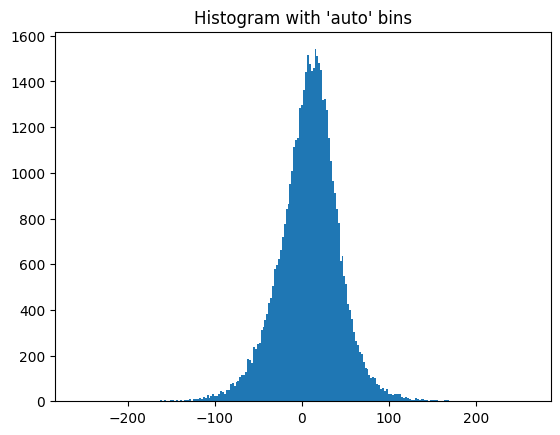

In [22]:
import numpy as np
import matplotlib.pyplot as plt

_ = plt.hist(songs[:,3], bins='auto')  # arguments are passed to np.histogram
plt.title("Histogram with 'auto' bins")
plt.show()

### 📝 Exercise 5 SGD regressor

Train and evaluate the SGD regressor (we are calculating the MAE on the validation data, which gives us a hint that this is a regression problem) on the songs dataset. Take the following steps:
- z-score the training and validation features
- find good settings for learning rate type and learning rate initial value.
  - r-squared on validation data 
  - mean absolute error on validation data  

In [19]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


def evaluate_sgd(X_train, y_train, X_val, y_val, learning_rate, eta0, loss='squared_error'):
    """Fit one SGD regressor and return its validation metrics.

    Parameters
    ----------
    X_train, y_train : training split used to update the model.
    X_val, y_val : validation split used only for evaluation.
    learning_rate : schedule for how the step size changes over time.
    eta0 : initial step size; larger values make bigger jumps.
    loss : error function optimized by SGD.
    """
    model = SGDRegressor(
        learning_rate=learning_rate,
        eta0=eta0,
        loss=loss,
        max_iter=5000,
        tol=1e-4,
        random_state=666,
    )
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    return {
        'learning_rate': learning_rate,
        'eta0': eta0,
        'loss': loss,
        'r2': r2_score(y_val, y_pred_val),
        'mae': mean_absolute_error(y_val, y_pred_val),
    }


# z-score the features so each input dimension is on a comparable scale.
scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train)
X_val_z = scaler.transform(X_val)

# eta0 candidates = initial learning-rate values we want to compare.
lr = [10 ** x for x in range(-6, 1)]

settings = []
for learning_rate in ['constant', 'optimal', 'invscaling']:
    for eta0 in lr:
        settings.append(
            evaluate_sgd(
                X_train_z,
                y_train,
                X_val_z,
                y_val,
                learning_rate=learning_rate,
                eta0=eta0,
            )
        )

best_mae = min(settings, key=lambda row: row['mae'])
best_r2 = max(settings, key=lambda row: row['r2'])

print("Best settings according to MAE {}".format(best_mae))
print("Best settings according to R2 {}".format(best_r2))

c:\Users\u517685\Documents\MATH\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Best settings according to MAE {'learning_rate': 'constant', 'eta0': 1e-06, 'loss': 'squared_error', 'r2': 0.21002739554922667, 'mae': 6.711694186403881}
Best settings according to R2 {'learning_rate': 'constant', 'eta0': 1e-05, 'loss': 'squared_error', 'r2': 0.21012695732317344, 'mae': 6.713302913476555}


### 📝 Exercise 6 Loss function

By default SGDRegressor tries to minimize the standard linear regression error function, that is sum of squared error. However this can be changed, via the `loss=` parameter. When `loss='squared_loss'`, sum of squared errors will be used. Other error functions available include [Huber loss](https://en.wikipedia.org/wiki/Huber_loss) (`loss='huber'`). Compared to squared loss, huber focuses less on outliers.
![](https://upload.wikimedia.org/wikipedia/commons/thumb/c/cc/Huber_loss.svg/600px-Huber_loss.svg.png)

Repeat the steps from the previous exercise, but include the tuning of the loss function.

In [20]:
# z-score the features so the optimizer sees comparable feature scales.
scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train)
X_val_z = scaler.transform(X_val)

# eta0 candidates = initial learning-rate values.
lr = [10 ** x for x in range(-6, 1)]

settings = []
for learning_rate in ['constant', 'optimal', 'invscaling']:
    # learning_rate = rate at which the step size changes during training.
    for loss in ['squared_error', 'huber']:
        # loss = objective that controls how prediction errors are penalized.
        for eta0 in lr:
            settings.append(
                evaluate_sgd(
                    X_train_z,
                    y_train,
                    X_val_z,
                    y_val,
                    learning_rate=learning_rate,
                    eta0=eta0,
                    loss=loss,
                )
            )

best_mae = min(settings, key=lambda row: row['mae'])
best_r2 = max(settings, key=lambda row: row['r2'])

print("Best settings according to MAE {}".format(best_mae))
print("Best settings according to R2 {}".format(best_r2))

c:\Users\u517685\Documents\MATH\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\u517685\Documents\MATH\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\u517685\Documents\MATH\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\u517685\Documents\MATH\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\U

Best settings according to MAE {'learning_rate': 'invscaling', 'eta0': 0.1, 'loss': 'huber', 'r2': 0.158042140007843, 'mae': 6.400742850393458}
Best settings according to R2 {'learning_rate': 'constant', 'eta0': 1e-05, 'loss': 'squared_error', 'r2': 0.21012695732317344, 'mae': 6.713302913476555}


<details>
<summary>What <code>learning_rate</code> means in SGD and how it affects optimization</summary>

`learning_rate` does **not** give one single numeric step size here. Instead, it chooses the **rule for how SGD updates its step size over time** while minimizing the loss.


In the loop

```python
for learning_rate in ['constant', 'optimal', 'invscaling']:
```

you are comparing three different optimization behaviors:

- `constant`: SGD keeps using the same step size throughout training (based on `eta0`). This can work well if `eta0` is chosen carefully, but it may oscillate around the minimum if the step is too large, or learn very slowly if the step is too small.
- `optimal`: scikit-learn automatically adjusts the step size using an internal heuristic. This often gives a strong baseline because the optimizer starts with larger moves and then becomes more cautious.
- `invscaling`: SGD starts from `eta0` and gradually shrinks the step size as training continues. This usually means faster exploration early on and more stable fine-tuning later.


Why this matters for optimization:

- the learning-rate schedule controls **how aggressively** the model moves downhill
- too aggressive: overshooting, bouncing, or unstable training
- too cautious: very slow progress and under-training
- a good schedule helps SGD move quickly at the start and settle down near a good minimum later

A useful mental model is: `eta0` sets the starting jump size, while `learning_rate` decides **whether those jumps stay the same or shrink during training**.
</details>

<details>
<summary>How to choose loss functions</summary>

Think of the horizontal axis as the residual $y - \hat{y}$: values near 0 are small mistakes, and values far from 0 are big misses.


- `squared_error` : $(y - \hat{y})^2$ rises fastest, so large errors are punished heavily. Use it when outliers are rare and you want the optimizer to focus strongly on big mistakes.
- `absolute loss` : $|y - \hat{y}|$ grows linearly, so large errors do not explode in importance. Use it when robustness matters more than aggressively chasing extreme points.
- `huber` : quadratic near 0 and linear for large $|y - \hat{y}|$. Use it when you want a good compromise: smooth optimization plus reduced sensitivity to outliers.


</details>

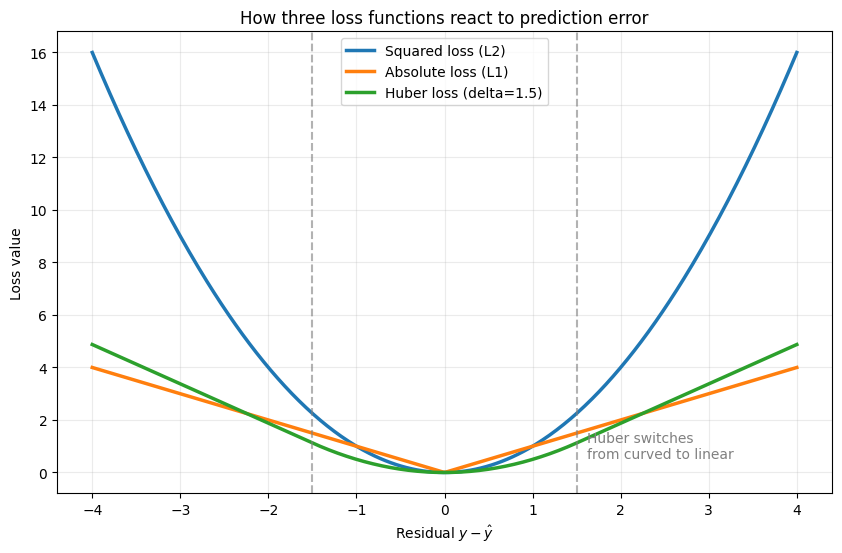

Intuition:
- Squared loss: best when you want to punish large errors very strongly.
- Absolute loss: more robust to outliers, but less smooth for optimization.
- Huber loss: a compromise; smooth near zero, robust for large errors.


In [ ]:


# residual = prediction error (y_true - y_pred).
# A loss function tells the optimizer how costly each error size is.
residual = np.linspace(-4, 4, 400)

# squared loss grows quadratically, so large errors become very expensive.
squared_loss = residual ** 2

# absolute loss grows linearly, so every extra unit of error costs the same amount.
absolute_loss = np.abs(residual)

# delta = threshold where Huber changes from quadratic to linear behavior.
delta = 1.5
huber_loss = np.where(
    np.abs(residual) <= delta,
    0.5 * residual ** 2,
    delta * (np.abs(residual) - 0.5 * delta),
)

plt.figure(figsize=(10, 6))
plt.plot(residual, squared_loss, label='Squared loss (L2)', linewidth=2.5)
plt.plot(residual, absolute_loss, label='Absolute loss (L1)', linewidth=2.5)
plt.plot(residual, huber_loss, label=f'Huber loss (delta={delta})', linewidth=2.5)

plt.axvline(delta, color='gray', linestyle='--', alpha=0.6)
plt.axvline(-delta, color='gray', linestyle='--', alpha=0.6)
plt.text(1.62, 0.55, 'Huber switches\nfrom curved to linear', color='gray')

plt.title('How three loss functions react to prediction error')
plt.xlabel(r'Residual $y - \hat{y}$')
plt.ylabel('Loss value')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

